# Multimodal Esophageal Cancer Status Prediction

## 1. Dataset Overview
This project utilizes a **Multimodal dataset** combining clinical biomarkers and imaging data. The goal is to leverage both data modalities for accurate classification.

* **Target Variable:** `target` (Binary: "Tumor Free" vs "With Tumor").
* **Features:**
    * **Clinical:** Patient demographics, pathology reports, and biomarkers.
    * **Imaging:** Pathology slide images processed via **EfficientNet**.

---

## 2. Workflow
1.  **Configuration:** Setting up paths and model parameters.
2.  **Data Ingestion:** Loading the pre-split train, validation, and test CSVs.
3.  **Preprocessing:**
    * *Clinical:* One-Hot Encoding categorical features and Standard Scaling numerical features.
    * *Imaging:* Decoding, resizing to `224x224`, and normalization.
4.  **Pipeline Creation:** Building efficient TensorFlow Data Loaders (`tf.data.Dataset`).
5.  **Visualization:** Checking target class balance.
6.  **Modeling:** Building a **Dual-Branch Neural Network** (CNN + Dense Fusion).
7.  **Training:** Using Early Stopping and Learning Rate Reduction.
8.  **Evaluation:** Accuracy plots, Classification Reports, and Confusion Matrices.
9.  **Analysis:** Qualitative audit of specific prediction instances.
10. **Deployment:** Saving the trained model and scalers.

In [3]:
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import joblib
import tqdm.keras
from tqdm.keras import TqdmCallback

# Set Global Visual Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("All Libraries have been imported successfully!")
print(f"TensorFlow Version: {tf.__version__}")

All Libraries have been imported successfully!
TensorFlow Version: 2.20.0


### Cell 03: Configuration & Data Loading
Defining file paths, model hyperparameters, and loading the datasets.

In [4]:
# --- 1. CONFIGURATION ---
DATA_DIR = r"E:\NLP\Assignment\1&2\Esophageal_Cancer_Project\Data\Multimodal"
MODELS_DIR = r"E:\NLP\Assignment\1&2\Esophageal_Cancer_Project\Models"
REPORTS_DIR = r"E:\NLP\Assignment\1&2\Esophageal_Cancer_Project\Reports"

# Model Parameters
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 0.0001

# Ensure output directories exist
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

# --- 2. LOAD DATA ---
print("Loading Datasets...")
train_df = pd.read_csv(os.path.join(DATA_DIR, "train_data.csv"))
val_df = pd.read_csv(os.path.join(DATA_DIR, "val_data.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test_data.csv"))

print(f"Train Shape: {train_df.shape}")
print(f"Val Shape:   {val_df.shape}")
print(f"Test Shape:  {test_df.shape}")

display(train_df.head())

Loading Datasets...
Train Shape: (2555, 75)
Val Shape:   (547, 75)
Test Shape:  (548, 75)


,informed_consent_verified,icd_o_3_site,icd_o_3_histology,tissue_prospective_collection_indicator,tissue_retrospective_collection_indicator,days_to_birth,country_of_birth,gender,height,weight,...,primary_pathology_number_of_lymphnodes_positive_by_ihc,primary_pathology_planned_surgery_status,primary_pathology_treatment_prior_to_surgery,primary_pathology_residual_tumor,primary_pathology_karnofsky_performance_score,primary_pathology_eastern_cancer_oncology_group,primary_pathology_radiation_therapy,primary_pathology_postoperative_rx_tx,target,image_path
0,YES,C15.3,8070/3,YES,NO,-25699,Vietnam,MALE,171.0,57.0,...,0.0,Surgery already performed,No Treatment,R0,80.0,3.0,NO,NO,0,E:\NLP\Assignment\1&2\Esophageal_Cancer_Projec...
1,YES,C15.4,8070/3,NO,YES,-26204,Vietnam,MALE,182.0,92.0,...,0.0,Surgery already performed,No Treatment,R0,80.0,1.0,NO,NO,1,E:\NLP\Assignment\1&2\Esophageal_Cancer_Projec...
2,YES,C15.4,8070/3,YES,NO,-16137,Vietnam,MALE,173.0,72.0,...,0.0,Surgery already performed,No Treatment,R0,60.0,1.0,NO,NO,0,E:\NLP\Assignment\1&2\Esophageal_Cancer_Projec...
3,YES,C15.4,8070/3,NO,YES,-23130,Brazil,MALE,167.0,64.0,...,9.0,Surgery already performed,No Treatment,R0,90.0,1.0,NO,NO,1,E:\NLP\Assignment\1&2\Esophageal_Cancer_Projec...
4,YES,C15.9,8140/3,YES,NO,-26534,United States,MALE,173.0,84.0,...,0.0,Yes,No Treatment,R0,60.0,2.0,YES,YES,1,E:\NLP\Assignment\1&2\Esophageal_Cancer_Projec...


### Cell 04: Data Cleaning & Preprocessing
This cell handles the dual-stream preprocessing: One-Hot Encoding/Scaling for clinical data and setting up image paths.

In [5]:
print("Preprocessing Clinical Features...")

# Define columns to exclude from features
non_feature_cols = ['target', 'image_path', 'person_neoplasm_cancer_status', 'patient_id']
feature_cols = [c for c in train_df.columns if c not in non_feature_cols]

# 1. Handle Categorical Data (One-Hot Encoding)
# Combine temporarily to align columns, then split
combined_df = pd.concat([train_df[feature_cols], val_df[feature_cols], test_df[feature_cols]], axis=0)
combined_dummies = pd.get_dummies(combined_df, drop_first=True)

# Split back into sets
train_clin_raw = combined_dummies.iloc[:len(train_df)]
val_clin_raw = combined_dummies.iloc[len(train_df):len(train_df)+len(val_df)]
test_clin_raw = combined_dummies.iloc[len(train_df)+len(val_df):]

# 2. Scale Data (StandardScaler)
# IMPORTANT: Fit ONLY on training data to prevent leakage
scaler = StandardScaler()
X_train_clin = scaler.fit_transform(train_clin_raw)
X_val_clin = scaler.transform(val_clin_raw)
X_test_clin = scaler.transform(test_clin_raw)

# Get Targets and Image Paths
y_train = train_df['target'].values
y_val = val_df['target'].values
y_test = test_df['target'].values

train_img_paths = train_df['image_path'].values
val_img_paths = val_df['image_path'].values
test_img_paths = test_df['image_path'].values

print(f"Clinical Features after processing: {X_train_clin.shape[1]}")

# 3. Image Processing Function
def process_image(path):
    """Reads an image, decodes JPEG, resizes, and applies EfficientNet preprocessing."""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = applications.efficientnet.preprocess_input(img)
    return img

Preprocessing Clinical Features...
Clinical Features after processing: 218


### Cell 05: Target Class Distribution Visualization
Visualizing the count of "Tumor Free" vs. "With Tumor" patients in the training set to check for class imbalance.

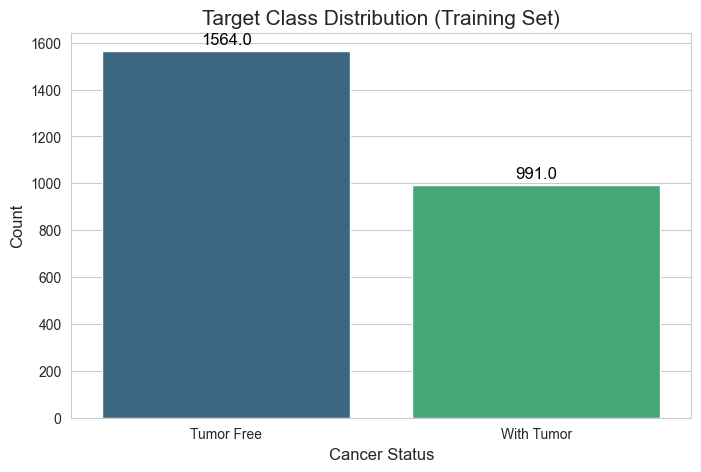

In [6]:
# Define class names for plotting
class_names = ["Tumor Free", "With Tumor"]

plt.figure(figsize=(8, 5))
ax = sns.countplot(x=y_train, palette='viridis')

plt.title('Target Class Distribution (Training Set)', fontsize=15)
plt.xlabel('Cancer Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
ax.set_xticklabels(class_names)

# Add count labels
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

### Cell 06: Pipeline Creation
Creating efficient tf.data.Dataset loaders that yield ((clinical_data, image_data), label) tuples for the multimodal model.

In [7]:
def create_dataset(clinical_data, image_paths, labels, shuffle=False):
    """Creates a tf.data.Dataset yielding ((clinical, image), label)."""

    # Create tensor slices
    dataset = tf.data.Dataset.from_tensor_slices((
        clinical_data,
        image_paths,
        labels
    ))

    # Map function to load image on the fly
    def map_func(clin, img_path, label):
        img = process_image(img_path)
        return (clin, img), label

    # Apply map
    dataset = dataset.map(map_func, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset

print("Creating Data Loaders...")
train_ds = create_dataset(X_train_clin, train_img_paths, y_train, shuffle=True)
val_ds = create_dataset(X_val_clin, val_img_paths, y_val, shuffle=False)
test_ds = create_dataset(X_test_clin, test_img_paths, y_test, shuffle=False)
print("Data Loaders Ready.")

Creating Data Loaders...
Data Loaders Ready.


### Cell 07: Model Architecture Definition
Defining the Multimodal Neural Network: One branch for clinical data, one for imaging (EfficientNet), followed by fusion and classification.

In [8]:
# Branch 1: Clinical (Dense Network)
clinical_input = layers.Input(shape=(X_train_clin.shape[1],), name="clinical_input")
x_clin = layers.Dense(64, activation="relu")(clinical_input)
x_clin = layers.BatchNormalization()(x_clin)
x_clin = layers.Dropout(0.3)(x_clin)
x_clin = layers.Dense(32, activation="relu")(x_clin)

# Branch 2: Imaging (EfficientNetB0)
image_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")
base_cnn = applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_tensor=image_input
)
base_cnn.trainable = False # Freeze the CNN weights for feature extraction

x_img = base_cnn.output
x_img = layers.GlobalAveragePooling2D()(x_img)
x_img = layers.Dropout(0.3)(x_img)

# Feature Fusion (Concatenation)
fused = layers.Concatenate(name="fusion_layer")([x_clin, x_img])

# Classification Head
x = layers.Dense(128, activation="relu")(fused)
x = layers.Dropout(0.4)(x)
output = layers.Dense(1, activation="sigmoid", name="cancer_prediction")(x)

# Create final model
model = models.Model(inputs=[clinical_input, image_input], outputs=output, name="Multimodal_Fusion_Model")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

print("Multimodal Model Summary")
model.summary()

Multimodal Model Summary


Model: "Multimodal_Fusion_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,234,116 (16.15 MB)

 Trainable params: 184,417 (720.38 KB)

 Non-trainable params: 4,049,699 (15.45 MB)

### Cell 08: Model Training
Compiling and training the multimodal model with Early Stopping and Learning Rate Reduction.

In [9]:
# Define Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.00001, verbose=1),
    TqdmCallback(verbose=1)
]

print("Starting Training...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=0 # TqdmCallback handles the progress bar
)

print("\nTraining Complete.")

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Starting Training...
Restoring model weights from the end of the best epoch: 15.

Training Complete.


### Cell 09: Performance Visualization
Plotting the Accuracy and Loss curves for both training and validation sets to visually assess convergence.

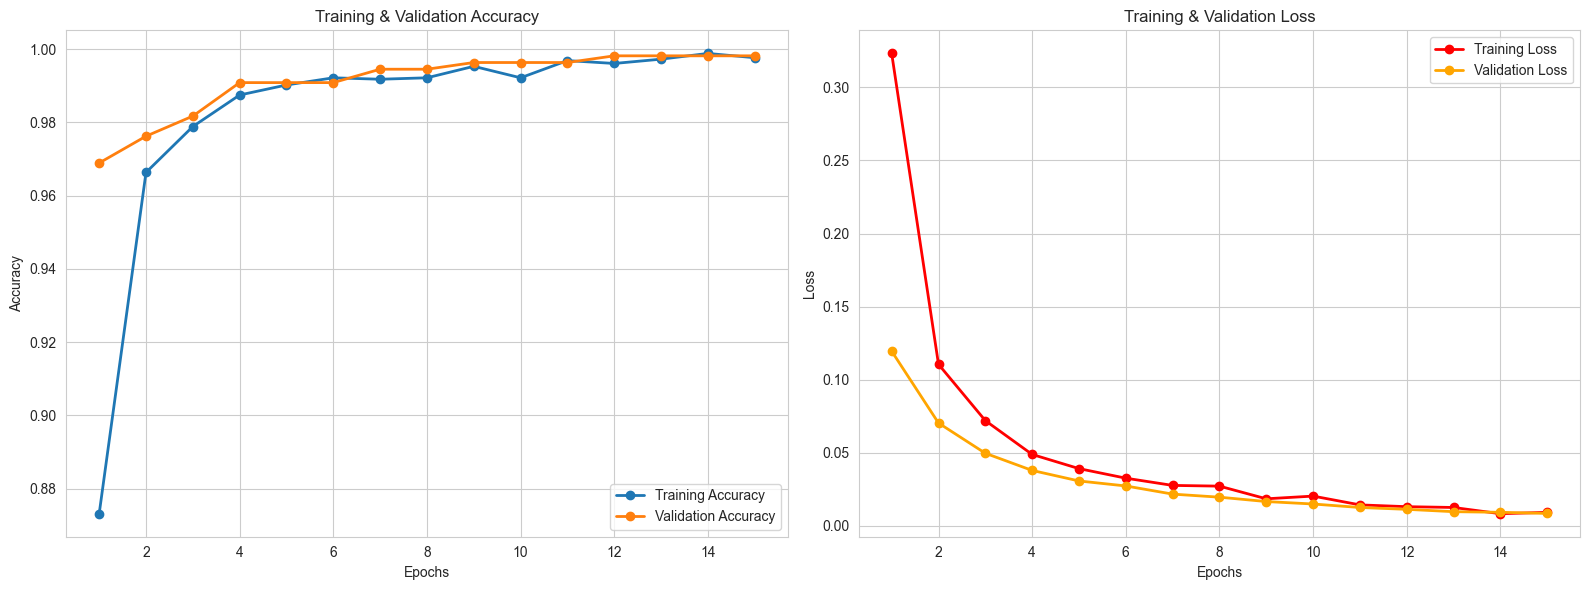

Final Training Accuracy:   0.9977
Final Validation Accuracy: 0.9982


In [10]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Accuracy
ax1.plot(epochs_range, acc, label='Training Accuracy', linewidth=2, marker='o')
ax1.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, marker='o')
ax1.set_title('Training & Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend(loc='lower right')
ax1.grid(True)

# Plot Loss
ax2.plot(epochs_range, loss, label='Training Loss', linewidth=2, marker='o', color='red')
ax2.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, marker='o', color='orange')
ax2.set_title('Training & Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend(loc='upper right')
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy:   {acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")

### Cell 10: Model Evaluation
Generating predictions on the unseen Test Set and producing a detailed Classification Report.

In [12]:
print("Running Final Evaluation on Test Set...")
results = model.evaluate(test_ds, verbose=0)

print(f"Test Set Accuracy: {results[1]*100:.2f}%")
print(f"Test Set AUC:      {results[2]:.4f}\n")

# Predictions
y_pred_probs = model.predict(test_ds, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Classification Report
target_names = ['TUMOR FREE', 'WITH TUMOR']

print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_names))

Running Final Evaluation on Test Set...
Test Set Accuracy: 99.64%
Test Set AUC:      1.0000

Classification Report
              precision    recall  f1-score   support

  TUMOR FREE       1.00      0.99      1.00       336
  WITH TUMOR       0.99      1.00      1.00       212

    accuracy                           1.00       548
   macro avg       1.00      1.00      1.00       548
weighted avg       1.00      1.00      1.00       548



### Cell 11: Confusion Matrix
Visualizing the Confusion Matrix as a heatmap to clearly see misclassifications

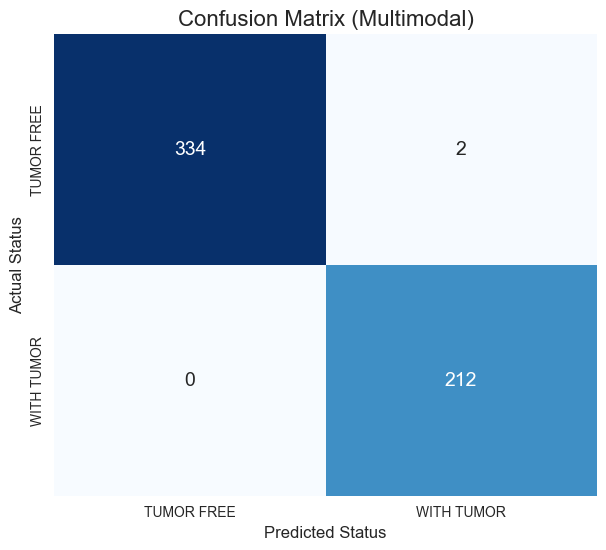

In [13]:
# Generate Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 14})

plt.title('Confusion Matrix (Multimodal)', fontsize=16)
plt.ylabel('Actual Status', fontsize=12)
plt.xlabel('Predicted Status', fontsize=12)
plt.show()

### Cell 12: Prediction Analysis
Displaying a detailed table of specific prediction instances, showing the confidence levels for correct and incorrect predictions.

In [14]:
# Get image filenames for reference
filenames = [os.path.basename(f) for f in test_img_paths]

# Identify indices
correct_indices = np.where(y_pred == y_test)[0]
incorrect_indices = np.where(y_pred != y_test)[0]

table_data = []

# Helper function to add rows
def add_to_table(indices, status, limit):
    count = 0
    for idx in indices:
        if count >= limit: break

        prob = y_pred_probs[idx][0]
        # Calculate confidence (distance from 0.5 threshold)
        confidence = prob if y_pred[idx] == 1 else 1 - prob

        table_data.append({
            "Status": status,
            "Image File": filenames[idx],
            "Actual": target_names[y_test[idx]],
            "Predicted": target_names[y_pred[idx]],
            "Confidence": f"{confidence:.2%}"
        })
        count += 1

# Add samples
add_to_table(correct_indices, "✅ Correct", 10)
add_to_table(incorrect_indices, "❌ Incorrect", 5)

# Display Table
results_df = pd.DataFrame(table_data)

def highlight_status(s):
    return ['background-color: #d4edda' if v == '✅ Correct' else 'background-color: #f8d7da' for v in s]

print("\nPrediction Analysis Table:")
display(results_df.style.apply(highlight_status, subset=['Status']))


Prediction Analysis Table:


,Status,Image File,Actual,Predicted,Confidence
0,✅ Correct,c5f46088-a8b5-4db8-8e61-51f0f3e2dd18.jpg,TUMOR FREE,TUMOR FREE,100.00%
1,✅ Correct,19b70245-0218-4018-a622-a3b87f778ffd.jpg,WITH TUMOR,WITH TUMOR,98.92%
2,✅ Correct,66f7ae10-730b-4d3d-931e-73285d65ef5f.jpg,WITH TUMOR,WITH TUMOR,99.99%
3,✅ Correct,9ebcd399-4725-43d4-8040-a4c4da888e0c.jpg,TUMOR FREE,TUMOR FREE,100.00%
4,✅ Correct,3da5cc47-6c2f-4e67-b5b8-3fb1ef7e6426.jpg,TUMOR FREE,TUMOR FREE,100.00%
5,✅ Correct,2172ed4d-adb9-4183-9858-7a9a56e91c4b.jpg,TUMOR FREE,TUMOR FREE,100.00%
6,✅ Correct,2b2b3c0b-12bf-4081-89fa-774f13ad4396.jpg,TUMOR FREE,TUMOR FREE,99.97%
7,✅ Correct,5d1184d7-f8f0-4800-b7c1-4117f773a3ef.jpg,TUMOR FREE,TUMOR FREE,100.00%
8,✅ Correct,d3c1a23b-c67d-41eb-969f-4283aa1d2f37.jpg,WITH TUMOR,WITH TUMOR,99.99%
9,✅ Correct,dc31d822-e062-4f78-813e-5f9b9ad2bcf7.jpg,WITH TUMOR,WITH TUMOR,99.96%


### Cell 13: Save Model & Results
Serializing and saving the trained Multimodal Model (.keras) and the Clinical Data Scaler (.pkl) to disk.

In [15]:
# Define Filenames
MODEL_ARCH = "Multimodal_CNN_Dense"
model_filename = f"Multimodal_Model_{MODEL_ARCH}.keras"
scaler_filename = f"Multimodal_Scaler_{MODEL_ARCH}.pkl"
report_filename = f"Multimodal_Report_{MODEL_ARCH}.txt"

model_save_path = os.path.join(MODELS_DIR, model_filename)
scaler_save_path = os.path.join(MODELS_DIR, scaler_filename)
report_save_path = os.path.join(REPORTS_DIR, report_filename)

# 1. Save Model and Scaler
print(f"Saving model artifacts to: {MODELS_DIR}...")
model.save(model_save_path)
joblib.dump(scaler, scaler_save_path)
print("Model and Scaler saved successfully.")

# 2. Save Report
class_report = classification_report(y_test, y_pred, target_names=target_names)
report_content = f"""Multimodal Model Evaluation Report
=========================================
Model Name:      {model_filename}
Architecture:    {MODEL_ARCH}
Input Features:  {X_train_clin.shape[1]} (Clinical) + {IMG_SIZE}x{IMG_SIZE} (Image)
=========================================

Overall Metrics:
----------------
Test Accuracy : {results[1]*100:.2f}%
Test AUC      : {results[2]:.4f}
Test Loss     : {results[0]:.4f}

Classification Report:
----------------------
{class_report}

Confusion Matrix:
-----------------
{cm}
"""

with open(report_save_path, "w") as f:
    f.write(report_content)
print(f"Report saved to: {report_save_path}")

Saving model artifacts to: E:\NLP\Assignment\1&2\Esophageal_Cancer_Project\Models...
Model and Scaler saved successfully.
Report saved to: E:\NLP\Assignment\1&2\Esophageal_Cancer_Project\Reports\Multimodal_Report_Multimodal_CNN_Dense.txt


### Cell 14: LIME Local Interpretation (Multimodal)
This cell uses LIME to explain individual predictions. It performs two analyses for a selected patient: one for their clinical data and one for their pathology image.

Explaining prediction for Patient Index: 10
Actual Label: WITH TUMOR
Model Prediction: With Tumor (99.71%)

Generating Clinical LIME Explanation...



Generating Image LIME Explanation (this may take a moment)...


  0%|          | 0/500 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


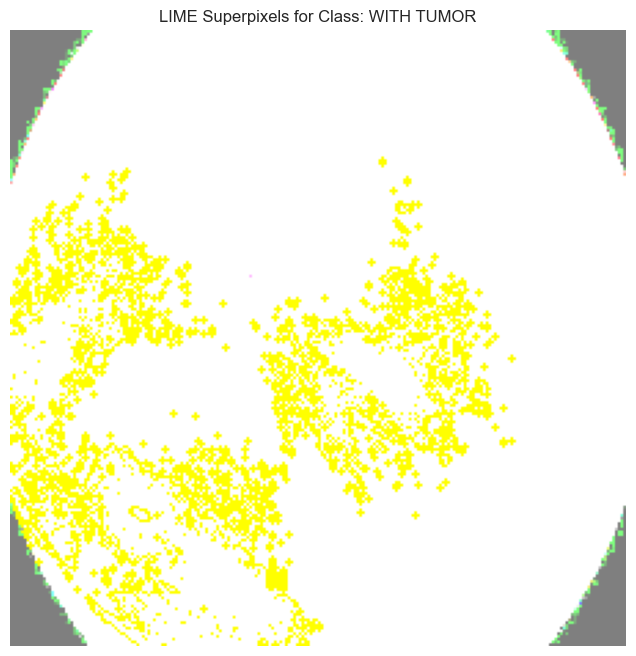

In [19]:
import lime
from lime import lime_tabular, lime_image
from skimage.segmentation import mark_boundaries
from IPython.display import display, HTML # Correct import for modern IPython

# 1. Select a specific patient to explain
IDX = 10
print(f"Explaining prediction for Patient Index: {IDX}")

# 2. Get the specific Clinical Data and Image for this patient
patient_clin = X_test_clin[IDX].reshape(1, -1)
target_img_path = test_img_paths[IDX]
patient_img_loaded = process_image(target_img_path).numpy().reshape(1, IMG_SIZE, IMG_SIZE, 3)

# 3. Check Model Prediction
print(f"Actual Label: {target_names[y_test[IDX]]}")
pred_prob = model.predict([patient_clin, patient_img_loaded], verbose=0)[0][0]
print(f"Model Prediction: {'With Tumor' if pred_prob > 0.5 else 'Tumor Free'} ({pred_prob:.2%})")

# --- 4. LIME for Clinical Features (Tabular) ---
def predict_fn_clinical(clinical_data_batch):
    """Wrapper: Varies clinical data while keeping the image constant."""
    n = clinical_data_batch.shape[0]
    repeated_imgs = np.repeat(patient_img_loaded, n, axis=0)
    probs = model.predict([clinical_data_batch, repeated_imgs], verbose=0)
    return np.hstack([1-probs, probs])

# Use the columns from the processed dataframe
final_feature_names = train_clin_raw.columns.tolist()

print("\nGenerating Clinical LIME Explanation...")
explainer_tab = lime_tabular.LimeTabularExplainer(
    training_data=X_train_clin,
    feature_names=final_feature_names,
    class_names=target_names,
    mode='classification'
)

exp_tab = explainer_tab.explain_instance(
    data_row=X_test_clin[IDX],
    predict_fn=predict_fn_clinical,
    num_features=10
)

# FIX: Manually display HTML to avoid ImportError
display(HTML(exp_tab.as_html(show_table=True)))

# --- 5. LIME for Imaging (Pixel) ---
def predict_fn_image(image_batch):
    """Wrapper: Varies image pixels while keeping clinical data constant."""
    n = image_batch.shape[0]
    repeated_clin = np.repeat(patient_clin, n, axis=0)
    probs = model.predict([repeated_clin, image_batch], verbose=0)
    return np.hstack([1-probs, probs])

print("\nGenerating Image LIME Explanation (this may take a moment)...")
explainer_img = lime_image.LimeImageExplainer()

exp_img = explainer_img.explain_instance(
    image=patient_img_loaded[0].astype('double'),
    classifier_fn=predict_fn_image,
    top_labels=1,
    hide_color=0,
    num_samples=500
)

# Show Image Plot
temp, mask = exp_img.get_image_and_mask(
    exp_img.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.figure(figsize=(8, 8))
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.title(f"LIME Superpixels for Class: {target_names[1]}")
plt.axis('off')
plt.show()

### Cell 15: SHAP Global Interpretation
This cell uses SHAP GradientExplainer to visualize the global importance of clinical features and valid pixel regions across the dataset.

Setting up SHAP for Clinical Features...
Calculating SHAP values (Fast Mode)...


  0%|          | 0/10 [00:00<?, ?it/s]

Global Clinical Feature Importance:


IndexError: list index out of range

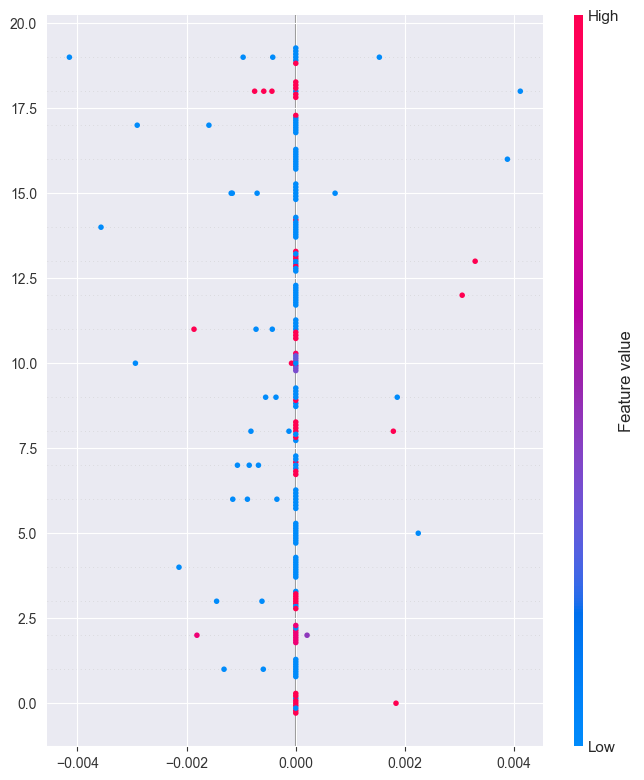

In [24]:
import shap
import IPython
import IPython.display
import numpy as np

# --- Compatibility Patch ---
if not hasattr(IPython.core.display, 'display'):
    IPython.core.display.display = IPython.display.display
if not hasattr(IPython.core.display, 'HTML'):
    IPython.core.display.HTML = IPython.display.HTML

shap.initjs()

print("Setting up SHAP for Clinical Features...")

# 1. Background Data (Clinical only)
# Use a tiny background sample for speed
background_clin = shap.sample(X_train_clin, 10)

# 2. Reference Image (Constant)
reference_image = process_image(test_img_paths[0]).numpy().reshape(1, IMG_SIZE, IMG_SIZE, 3)

# 3. Memory-Safe Wrapper Function
def model_wrapper(clinical_data_batch):
    """
    Processes the large batch of synthetic data in small chunks to prevent MemoryError.
    """
    # Force a small batch size to keep RAM usage low
    mini_batch_size = 10
    n_total = clinical_data_batch.shape[0]
    all_predictions = []

    # Process in loop
    for i in range(0, n_total, mini_batch_size):
        # Slice clinical data
        clin_mini_batch = clinical_data_batch[i : i + mini_batch_size]
        current_size = clin_mini_batch.shape[0]

        # Create image batch ONLY for this small slice
        # This uses < 50MB of RAM instead of 65GB
        img_mini_batch = np.repeat(reference_image, current_size, axis=0)

        # Predict
        preds = model.predict([clin_mini_batch, img_mini_batch], verbose=0)
        all_predictions.append(preds)

    # Combine results
    return np.vstack(all_predictions).flatten()

# 4. Initialize & Calculate
explainer = shap.KernelExplainer(model_wrapper, background_clin)
test_sample_clin = X_test_clin[:10]

print("Calculating SHAP values (Fast Mode)...")
# nsamples=50 makes this run much faster
shap_values = explainer.shap_values(test_sample_clin, nsamples=50)

# 5. Visualization
print("Global Clinical Feature Importance:")
plt.figure()
shap.summary_plot(shap_values, test_sample_clin, feature_names=feature_cols)
plt.show()